In [10]:
# Install only wfdb, ignoring systemic dependency conflicts to prevent Colab kernel crashes
!pip install wfdb --no-dependencies

import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

import wfdb
from scipy.signal import butter, filtfilt
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility across runs
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Hardware acceleration config (utilizing T4 GPU if available)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Constants for heartbeat signal segmentation
FS          = 360
HALF_WINDOW = 90
BEAT_LEN    = 2 * HALF_WINDOW

Using device: cuda


In [11]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/ECG_Project'
os.makedirs(DRIVE_PATH, exist_ok=True)
DATA_DIR = os.path.join(DRIVE_PATH, 'mitdb')

if not os.path.exists(DATA_DIR):
    print('Downloading mitdb from PhysioNet...')
    wfdb.dl_database('mitdb', DATA_DIR)
    print('Download completed.')
else:
    print(f'Dataset already present in {DATA_DIR}.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset already present in /content/drive/MyDrive/ECG_Project/mitdb.


In [12]:
def get_aami_category(symbol):
    mapping = {
        'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal',
        'A': 'SVEB', 'a': 'SVEB', 'J': 'SVEB', 'S': 'SVEB',
        'V': 'VEB', 'E': 'VEB',
        'F': 'Fusion',
        '/': 'Paced', 'f': 'Paced', 'Q': 'Unknown'
    }
    return mapping.get(symbol, 'Other')

DS1_RECORDS = ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119',
               '122', '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']

DS2_RECORDS = ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202',
               '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']

import random
random.seed(SEED)
shuffled_ds1 = DS1_RECORDS.copy()
random.shuffle(shuffled_ds1)

split_idx = int(0.8 * len(shuffled_ds1))
TRAIN_RECORDS = shuffled_ds1[:split_idx]
VAL_RECORDS   = shuffled_ds1[split_idx:]
TEST_RECORDS  = DS2_RECORDS

print(f'Train records (DS1 sub): {TRAIN_RECORDS}')
print(f'Val records (DS1 sub)  : {VAL_RECORDS}')
print(f'Test records (DS2)      : {TEST_RECORDS}')

Train records (DS1 sub): ['230', '114', '108', '207', '119', '201', '208', '220', '115', '203', '215', '205', '122', '106', '124', '112', '209']
Val records (DS1 sub)  : ['116', '118', '101', '109', '223']
Test records (DS2)      : ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']


In [13]:
def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=360, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def load_records_hybrid(record_list, dataset_name="Dataset"):
    x_data = []
    intervals_data = []
    y_data = []
    label_map = {'Normal': 0, 'SVEB': 1, 'VEB': 2, 'Fusion': 3}

    for record_id in tqdm(record_list, desc=f"Processing {dataset_name}"):
        path = os.path.join(DATA_DIR, record_id)
        record = wfdb.rdrecord(path)
        signal = bandpass_filter(record.p_signal[:, 0])

        annotation = wfdb.rdann(path, 'atr')
        peaks = annotation.sample
        symbols = annotation.symbol

        for i in range(len(peaks)):
            category = get_aami_category(symbols[i])
            if category in label_map:
                start, end = peaks[i] - HALF_WINDOW, peaks[i] + HALF_WINDOW
                if start > 0 and end < len(signal):
                    segment = signal[start:end]
                    segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

                    pre_rr = peaks[i] - peaks[i-1] if i > 0 else FS
                    post_rr = peaks[i+1] - peaks[i] if i < len(peaks)-1 else FS

                    intervals = np.array([pre_rr / FS, post_rr / FS], dtype=np.float32)

                    x_data.append(segment)
                    intervals_data.append(intervals)
                    y_data.append(label_map[category])

    return np.array(x_data), np.array(intervals_data), np.array(y_data)

In [14]:
print("Starting hybrid feature extraction...")
X_train, Int_train, y_train = load_records_hybrid(TRAIN_RECORDS, "Train Set")
X_val, Int_val, y_val = load_records_hybrid(VAL_RECORDS, "Validation Set")
X_test, Int_test, y_test = load_records_hybrid(TEST_RECORDS, "Test Set (DS2)")

inv_label_map = {0: 'Normal (N)', 1: 'SVEB (S)', 2: 'VEB (V)', 3: 'Fusion (F)'}

def print_clean_dist(y, title):
    counts = Counter([int(i) for i in y])
    print(f"\n{title} Distribution:")
    for label, count in sorted(counts.items()):
        print(f" - {inv_label_map[label]}: {count}")

print_clean_dist(y_train, "Train")
print_clean_dist(y_val, "Validation")
print_clean_dist(y_test, "Test")

Starting hybrid feature extraction...


Processing Test Set (DS2): 100%|██████████| 22/22 [00:08<00:00,  2.63it/s]



Train Distribution:
 - Normal (N): 34995
 - SVEB (S): 771
 - VEB (V): 3152
 - Fusion (F): 398

Validation Distribution:
 - Normal (N): 10861
 - SVEB (S): 173
 - VEB (V): 636
 - Fusion (F): 16

Test Distribution:
 - Normal (N): 44246
 - SVEB (S): 1837
 - VEB (V): 3220
 - Fusion (F): 388


In [15]:
# Convert NumPy arrays into multi-input PyTorch Tensors
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
Int_train_t = torch.FloatTensor(Int_train)
y_train_t = torch.LongTensor(y_train)

X_val_t = torch.FloatTensor(X_val).unsqueeze(1)
Int_val_t = torch.FloatTensor(Int_val)
y_val_t = torch.LongTensor(y_val)

X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
Int_test_t = torch.FloatTensor(Int_test)
y_test_t = torch.LongTensor(y_test)

# Configure DataLoaders for train, validation, and test partitions
train_loader = DataLoader(TensorDataset(X_train_t, Int_train_t, y_train_t), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, Int_val_t, y_val_t), batch_size=256, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, Int_test_t, y_test_t), batch_size=256, shuffle=False)

# Pure de Chazal (2004) Class Weighting Formula (No square root smoothing)
# As specified on page 1201 (Section E) of the paper, this reduces the relative
# contribution of large classes to the training process by setting w_k = 400 / N_k
class_counts = np.bincount(y_train)
class_weights = np.zeros_like(class_counts, dtype=np.float32)

for i, count in enumerate(class_counts):
    if count > 400:
        class_weights[i] = 400.0 / count  # Force massive classes to contribute max 400 equivalent samples
    else:
        class_weights[i] = 1.0  # Rare classes keep maximum focus weight

# Normalize weights so they sum up to 1 before moving to device
class_weights = class_weights / class_weights.sum()
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print(f"Pure de Chazal formulation weights: {class_weights}")

Pure de Chazal formulation weights: [0.00689755 0.3130735  0.07657984 0.60344917]


In [16]:
class HybridECGNet(nn.Module):
    def __init__(self, num_classes=4):
        super(HybridECGNet, self).__init__()

        # 1D-CNN pipeline dedicated to morphology pattern learning
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        # Fully connected layer fusing spatial morphology (128) + timing intervals (2)
        # 128 (CNN Morphology Features) + 2 (Pre/Post RR Timing Features) = 130 inputs
        self.fc1 = nn.Linear(128 + 2, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x, intervals):
        # 1. Morphological path
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.mean(x, dim=2)  # Global Average Pooling layer

        # 2. Context Fusion (Morphology + Rhythm)
        combined = torch.cat((x, intervals), dim=1)

        # 3. Dense classification layers
        combined = F.relu(self.fc1(combined))
        combined = self.dropout(combined)
        return self.fc2(combined)

# Instantiate network, loss function with pure weights, and setup the optimizer
model = HybridECGNet(num_classes=4).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# Lower learning rate (from 0.001 to 0.0002) to train smoothly with aggressive pure weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002)

print(model)

HybridECGNet(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=130, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)


In [17]:
EPOCHS = 35  # Increased epochs to let the slower learning rate converge fully
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

print("Starting training with pure weights and lower learning rate...")
for epoch in range(EPOCHS):
    # Phase A: Training loop
    model.train()
    running_train_loss = 0.0
    for inputs, intervals, labels in train_loader:
        inputs, intervals, labels = inputs.to(DEVICE), intervals.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs, intervals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    # Phase B: Evaluation/Validation loop
    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0
    with torch.no_grad():
        for inputs, intervals, labels in val_loader:
            inputs, intervals, labels = inputs.to(DEVICE), intervals.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs, intervals)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_predictions.double() / len(val_loader.dataset)

    # Checkpoint logic to save only if valid loss reaches a new local minimum
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"--> Saved best model checkpoint at epoch {epoch+1}")

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.item())

    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

Starting training with pure weights and lower learning rate...
--> Saved best model checkpoint at epoch 1
Epoch 1/35 -> Train Loss: 0.9493 | Val Loss: 1.2333 | Val Acc: 44.10%
--> Saved best model checkpoint at epoch 2
Epoch 2/35 -> Train Loss: 0.5205 | Val Loss: 1.1147 | Val Acc: 59.50%
Epoch 3/35 -> Train Loss: 0.3800 | Val Loss: 1.7249 | Val Acc: 44.38%
Epoch 4/35 -> Train Loss: 0.3152 | Val Loss: 1.7641 | Val Acc: 49.04%
Epoch 5/35 -> Train Loss: 0.2859 | Val Loss: 1.9981 | Val Acc: 37.96%
Epoch 6/35 -> Train Loss: 0.2437 | Val Loss: 1.9616 | Val Acc: 47.56%
Epoch 7/35 -> Train Loss: 0.2306 | Val Loss: 2.1388 | Val Acc: 45.88%
Epoch 8/35 -> Train Loss: 0.2224 | Val Loss: 2.6157 | Val Acc: 39.32%
Epoch 9/35 -> Train Loss: 0.2046 | Val Loss: 3.1940 | Val Acc: 20.77%
Epoch 10/35 -> Train Loss: 0.2029 | Val Loss: 3.1863 | Val Acc: 26.99%
Epoch 11/35 -> Train Loss: 0.1799 | Val Loss: 2.5732 | Val Acc: 36.08%
Epoch 12/35 -> Train Loss: 0.1823 | Val Loss: 2.4548 | Val Acc: 27.54%
Epoch 13


--- CLASSIFICATION REPORT (AAMI/DE CHAZAL HYBRID MODEL) ---
              precision    recall  f1-score   support

  Normal (N)       0.96      0.85      0.90     44246
    SVEB (S)       0.09      0.29      0.13      1837
     VEB (V)       0.82      0.88      0.85      3220
  Fusion (F)       0.00      0.00      0.00       388

    accuracy                           0.82     49691
   macro avg       0.47      0.50      0.47     49691
weighted avg       0.91      0.82      0.86     49691



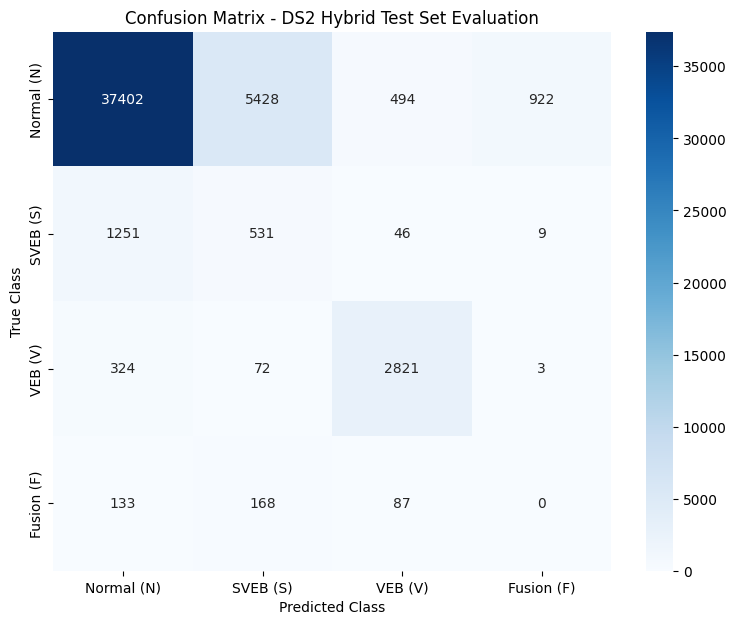

In [18]:
model.eval()
all_preds = []
all_labels = []

model.load_state_dict(torch.load('best_model.pth'))

with torch.no_grad():
    for inputs, intervals, labels in test_loader:
        inputs, intervals = inputs.to(DEVICE), intervals.to(DEVICE)
        outputs = model(inputs, intervals)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = ['Normal (N)', 'SVEB (S)', 'VEB (V)', 'Fusion (F)']
print("\n--- CLASSIFICATION REPORT (AAMI/DE CHAZAL HYBRID MODEL) ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - DS2 Hybrid Test Set Evaluation')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()